# Prithvi-WxC Inference

This notebook performs automated inference using the Prithvi-WxC model.

## Setup

### Required Software

The ``prithvi_tc.yml`` file defines a conda environment containing all required software for running the inference.

### Input Data

This notebook expects the input data to be organized as follows:



In [1]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
%ls -ltrh

total 1.6M
-rw-r--r-- 1 simon simon  600K Nov 17 21:06 http_cache.sqlite
-rw------- 1 simon simon   620 Nov 17 21:50 model.toml
-rw-rw-r-- 1 simon simon 1016K Nov 17 22:09 prithvi_tc_inference.ipynb


In [3]:
%env PRITHVI_DATA_PATH=/data1/prithvi_precip/data/scaling_factors

env: PRITHVI_DATA_PATH=/data1/prithvi_precip/data/scaling_factors


In [4]:
from pytorch_retrieve.architectures import load_and_compile_model
from pytorch_retrieve.training import load_weights
mdl = load_and_compile_model("model.toml")
load_weights(
    {"backbone": "/data1/prithvi_precip/models/prithvi.wxc.rollout.2300m.v1.pt"},
    mdl
)

In [5]:
import torch
from typing import Dict

def post_process_results(inpt: Dict[str, torch.Tensor], results: Dict[str, torch.Tensor]) -> xr.Dataset:
    """
    Extracts surface winds, surface pressure and 850 winds from forecast results.

    Args:
        inpt: The batch containing the input data.
        results: A dictionary containing the forecast results.

    Return:
        An xarray.Dataset containing the results to be stored.
    """
    static = inpt["static"]
    if static.dim() == 5:
        lats = np.rad2deg(inpt["static"][0, 0, 0, :, 0].float().cpu().numpy())
        lons = np.rad2deg(inpt["static"][0, 0, 1, 0, :].float().cpu().numpy())
    else:
        lats = np.rad2deg(inpt["static"][0, 0, :, 0].float().cpu().numpy())
        lons = np.rad2deg(inpt["static"][0, 1, 0, :].float().cpu().numpy())

    dataset = xr.Dataset({
        "latitude": (("latitude",), lats),
        "longitude": (("longitude",), lons)
    })

    pred = results["y"]
    pred = np.stack([step[:, [9, 17, 18, -18, -4]].float().cpu().numpy() for step in pred], axis=1)
    slp = pred[:, :, 0]
    u10 = pred[:, :, 1]
    v10 = pred[:, :, 2]
    u850 = pred[:, :, 3]
    v850 = pred[:, :, 4]

    dataset["slp"] = (("batch", "step", "latitude", "longitude"), slp)
    dataset["u10"] = (("batch", "step", "latitude", "longitude"), u10)
    dataset["v10"] = (("batch", "step", "latitude", "longitude"), v10)
    dataset["u850"] = (("batch", "step", "latitude", "longitude"), u850)
    dataset["v850"] = (("batch", "step", "latitude", "longitude"), v850)

    for var in ["slp", "u10", "v10", "u850", "v850"]:
        dataset[var].encoding = {"dtype": "float32", "zlib": True}
    return dataset


In [6]:
from prithvi_precip.forecast.data_loaders import AutoregressiveForecastLoader

In [33]:
data_loader = AutoregressiveForecastLoader(
    "/data1/prithvi_precip/data/test_data/",
    init_times = np.array([np.datetime64("2022-02-01T06:00:00")]),
    n_steps=3,
    input_time=6,
    center_meridionally=False,
    full_climatology=True
)

len(data_loader)

1

In [34]:
data_loader.full_climatology

True

In [35]:
from prithvi_precip.forecast.runners import run_autoregressive_forecast

In [37]:
from prithvi_precip.forecast.runners import run_autoregressive_forecast

run_autoregressive_forecast(
    mdl,
    data_loader,
    "/data1/prithvi_precip/results/prithvi_tc",
    post_process_fn=post_process_results,
    device="cuda:1",
    dtype=torch.float32,
)

  0%|                                                                                                                | 0/1 [00:01<?, ?it/s]


KeyboardInterrupt: 

## Visualize Results

In [38]:
result_files = sorted(list(Path("/data1/prithvi_precip/results/prithvi_tc").glob("*.nc")))

In [39]:
result_files

[PosixPath('/data1/prithvi_precip/results/prithvi_tc/forecast_202202010600.nc')]

In [42]:
results = xr.load_dataset(result_files[-1])
results_ref = xr.load_dataset(result_files[-1].parent.parent / result_files[-1].name)

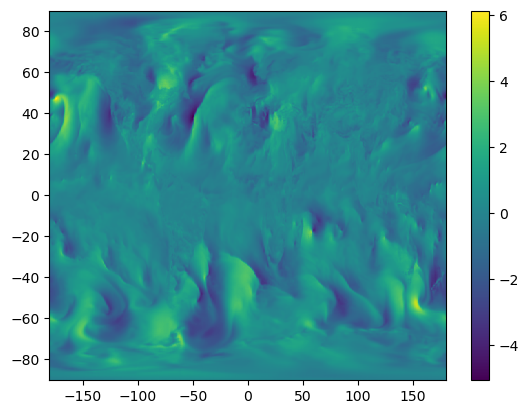

In [49]:
plt.pcolormesh(results.longitude, results.latitude, results_ref.v10[2])
#plt.xlim(-110, -60)
#plt.ylim(10, 50)
plt.colorbar()

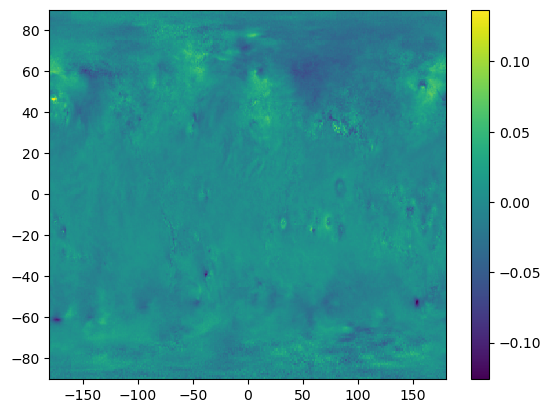

In [50]:
plt.pcolormesh(
    results.longitude,
    results.latitude,
    results.slp[2] - results_ref.slp[2]
)
plt.colorbar()

In [44]:
plt.pcolormesh(results.longitude, results.latitude, results.u10[3])
#plt.xlim(-110, -60)
#plt.ylim(10, 50)

IndexError: index 3 is out of bounds for axis 0 with size 3

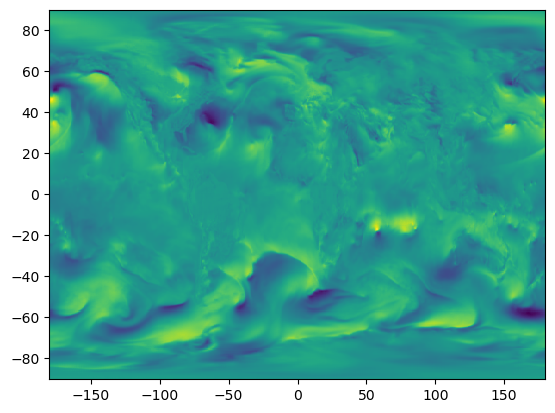

In [15]:
plt.pcolormesh(results.longitude, results.latitude, results.u10[3])
#plt.xlim(-110, -60)
#plt.ylim(10, 50)

In [27]:
import numpy as np
from PrithviWxC.download import get_prithvi_wxc_input

initialization_time = np.datetime64("2022-02-01T06:00:00")
get_prithvi_wxc_input(
    initialization_time,
    6, # The time difference in hours between consecutive model steps.
    6 * 4, # Total maximum lead time.
    "../data/merra-2",
    "../data/"
)

[21:46:59] INFO     Downloading MERRA-2 files.                                                      ]8;id=921797;file:///home/simon/src/Prithvi-WxC/PrithviWxC/download.py\download.py]8;;\:]8;id=701467;file:///home/simon/src/Prithvi-WxC/PrithviWxC/download.py#548\548]8;;\

Extracting input data: 100%|██████████████████████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 16743.73it/s]


           INFO     Downloading climatology files.                                                  ]8;id=247673;file:///home/simon/src/Prithvi-WxC/PrithviWxC/download.py\download.py]8;;\:]8;id=108345;file:///home/simon/src/Prithvi-WxC/PrithviWxC/download.py#564\564]8;;\

In [29]:
from PrithviWxC.configs import get_model_config
from PrithviWxC.dataloaders.merra2_rollout import Merra2RolloutDataset

# Workshop participants can use the 'small' Prithvi-WxC model
# Remote users will need to use 'large_rollout'.
config_name = "large_rollout"
prithvi_config = get_model_config(config_name, data_dir="../../data")

dataset = Merra2RolloutDataset(
    time_range=("2022-02-01T00:00:00", "2022-02-02T15:00:00"),
    lead_time=18,
    input_time=-6,
    data_path_surface="../data/merra-2",
    data_path_vertical="../data/merra-2",
    climatology_path_surface="../data/climatology",
    climatology_path_vertical="../data/climatology",
    surface_vars=prithvi_config.surface_vars,
    static_surface_vars=prithvi_config.static_surface_vars,
    vertical_vars=prithvi_config.vertical_vars,
    levels=prithvi_config.levels,
    positional_encoding="fourier",
)
assert 0 < len(dataset), "There doesn't seem to be any valid data."

In [ ]:
kjkk

In [30]:
prithvi_config

PrithviWxCConfig(surface_vars=['EFLUX', 'GWETROOT', 'HFLUX', 'LAI', 'LWGAB', 'LWGEM', 'LWTUP', 'PS', 'QV2M', 'SLP', 'SWGNT', 'SWTNT', 'T2M', 'TQI', 'TQL', 'TQV', 'TS', 'U10M', 'V10M', 'Z0M'], vertical_vars=['CLOUD', 'H', 'OMEGA', 'PL', 'QI', 'QL', 'QV', 'T', 'U', 'V'], static_surface_vars=['FRACI', 'FRLAND', 'FROCEAN', 'PHIS'], levels=[34.0, 39.0, 41.0, 43.0, 44.0, 45.0, 48.0, 51.0, 53.0, 56.0, 63.0, 68.0, 71.0, 72.0], in_channels=160, input_size_time=2, in_channels_static=8, input_scalers_epsilon=0.0, static_input_scalers_epsilon=0.0, n_lats_px=360, n_lons_px=576, patch_size_px=[2, 2], mask_unit_size_px=[30, 32], embed_dim=2560, n_blocks_encoder=12, n_blocks_decoder=2, mlp_multiplier=4, n_heads=16, dropout=0.0, drop_path=0.0, residual='climate', masking_mode='both', encoder_shifting=False, decoder_shifting=True, parameter_dropout=0.0, positional_encoding='fourier', checkpoint_encoder=[], checkpoint_decoder=[])

In [31]:
import PrithviWxC
PrithviWxC.__file__

'/home/simon/src/Prithvi-WxC/PrithviWxC/__init__.py'

In [32]:
batch = next(iter(dataset))

In [33]:
import torch
from PrithviWxC.dataloaders.merra2_rollout import preproc

padding = {"level": [0, 0], "lat": [0, -1], "lon": [0, 0]}
data = next(iter(dataset))
batch_ref = preproc([data], padding)

In [34]:
init_times, valid_times, batch = next(iter(data_loader))

In [35]:
torch.where((0.0 < torch.abs(batch["x"] - batch_ref["x"][:, :3])))

(tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64))

In [36]:
torch.where((0.0 < torch.abs(batch["static"][:, :3] - batch_ref["statics"][:, :3])))

(tensor([0, 0, 0,  ..., 0, 0, 0]),
 tensor([0, 0, 0,  ..., 2, 2, 2]),
 tensor([0, 0, 0,  ..., 1, 1, 1]),
 tensor([  3,   3,   3,  ..., 359, 359, 359]),
 tensor([  0,   1,   2,  ..., 566, 570, 574]))

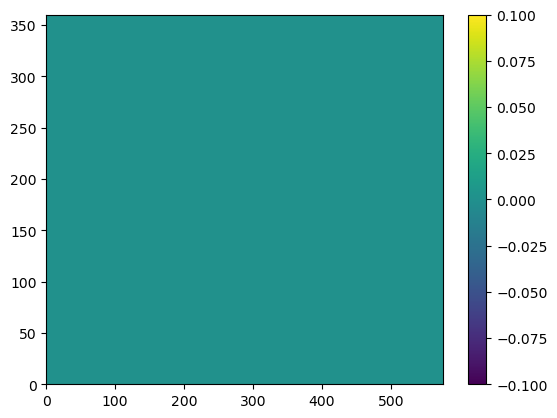

In [38]:
plt.pcolormesh(batch["static"][0, 0, 2] - batch_ref["statics"][0, 0, 2])
plt.colorbar()

In [39]:
torch.where((0.0 < torch.abs(batch["climate"][:, :3] - batch_ref["climates"][:, :3])))

(tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64),
 tensor([], dtype=torch.int64))

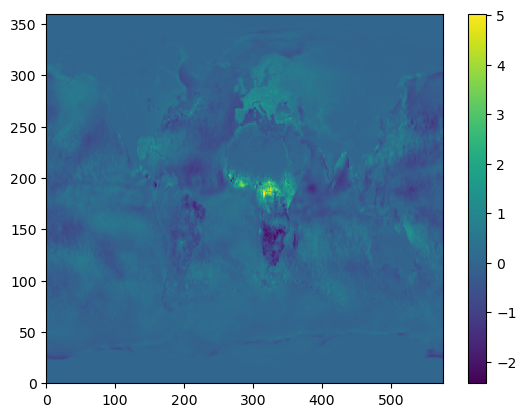

In [52]:
plt.pcolormesh(batch["climate"][0, 0, 0] - batch_ref["climates"][0, 0, 0])
plt.colorbar()

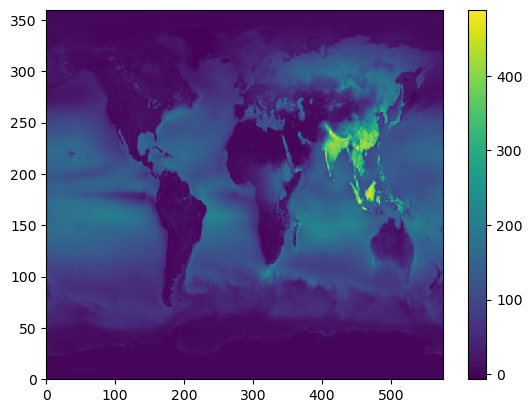

In [62]:
plt.pcolormesh(batch["climate"][0, 0, 0])
plt.colorbar()